In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("../datasets/processed/master_accident_dataset.csv")

print("✅ Clean Dataset Loaded")
print(df.shape)

✅ Clean Dataset Loaded
(20000, 27)


In [2]:
sns.set_style("whitegrid")

print("✅ Visualization Style Ready")

✅ Visualization Style Ready


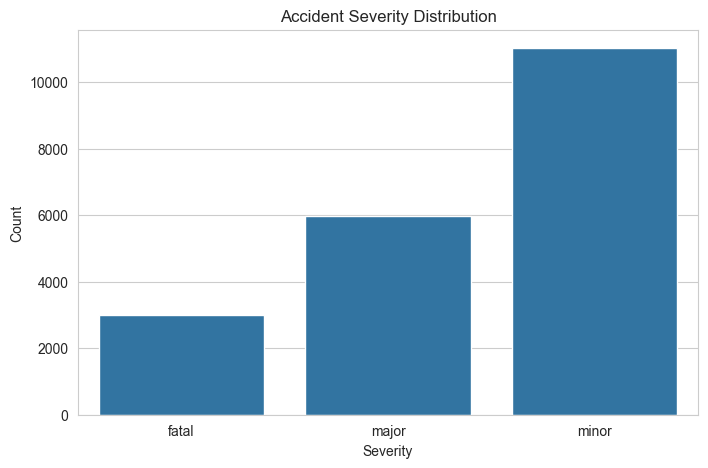

In [3]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='accident_severity',
    data=df
)

plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")

plt.show()

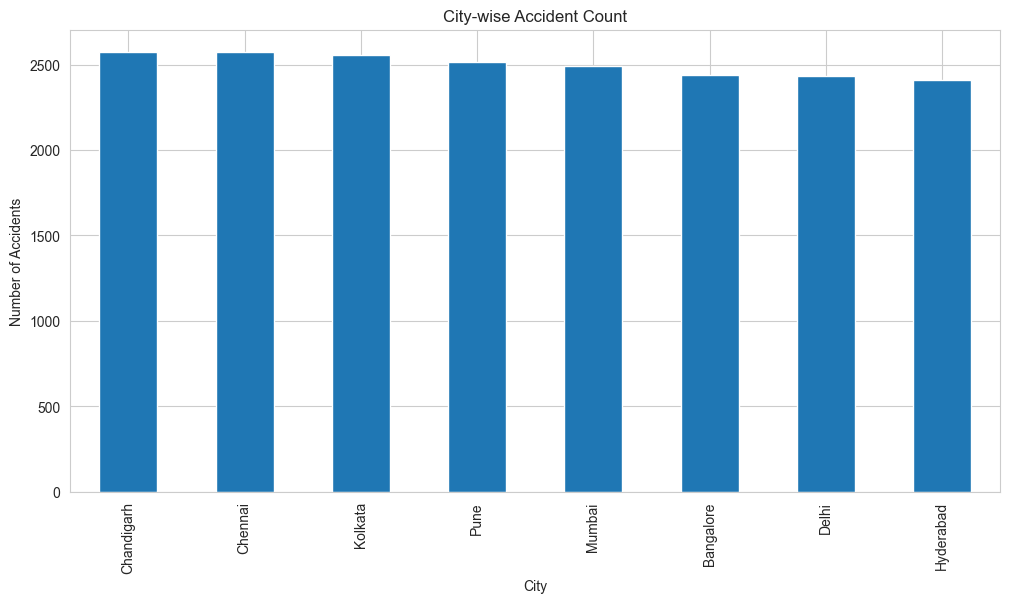

In [4]:
plt.figure(figsize=(12,6))

df['city'].value_counts().plot(kind='bar')

plt.title("City-wise Accident Count")
plt.xlabel("City")
plt.ylabel("Number of Accidents")

plt.show()

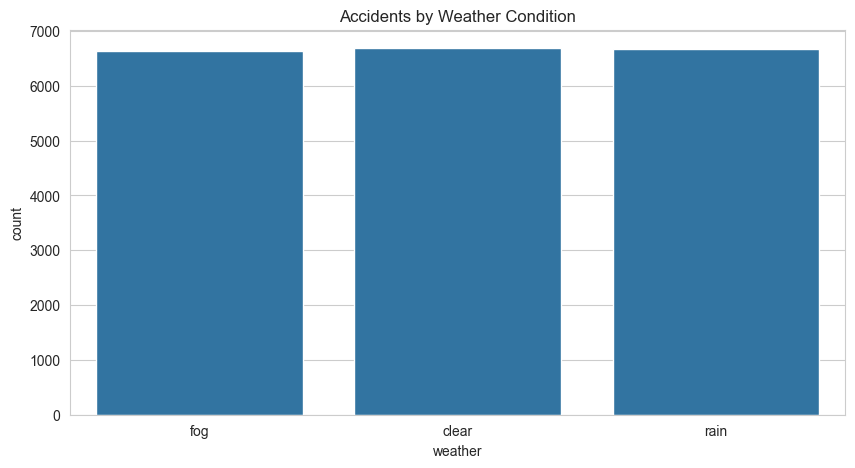

In [5]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='weather',
    data=df
)

plt.title("Accidents by Weather Condition")

plt.show()

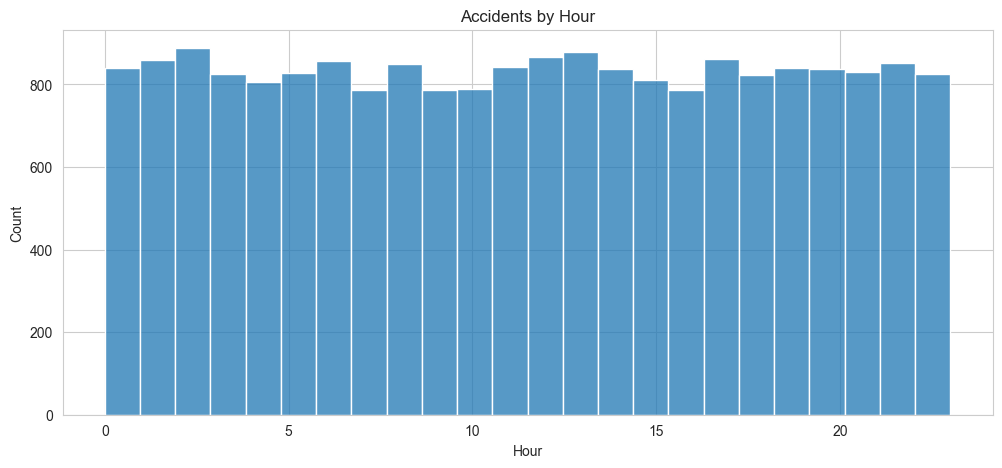

In [6]:
plt.figure(figsize=(12,5))

sns.histplot(df['hour'], bins=24)

plt.title("Accidents by Hour")

plt.xlabel("Hour")

plt.show()

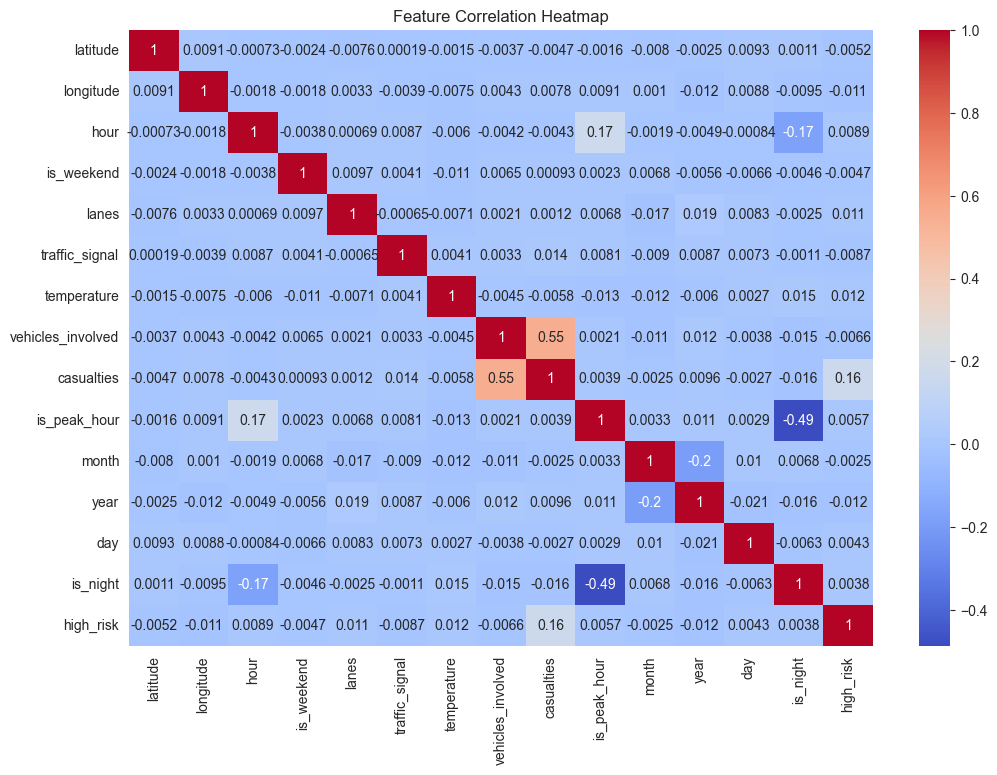

In [7]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [8]:
import folium

In [10]:
india_map = folium.Map(
    location=[22.5937, 78.9629],
    zoom_start=5
)

india_map

In [11]:
india_map

In [12]:
india_map

In [13]:
india_map.save("india_accidents_map.html")


In [14]:
import folium

# Create India base map
india_map = folium.Map(
    location=[22.5937, 78.9629],
    zoom_start=5
)

# Add first 500 accident points
for index, row in df.head(500).iterrows():

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        popup=f"""
        City: {row['city']} <br>
        Severity: {row['accident_severity']} <br>
        Weather: {row['weather']}
        """,
        color='red',
        fill=True,
        fill_opacity=0.7
    ).add_to(india_map)

# Save map
india_map.save("india_accidents_hotspots.html")

india_map

In [15]:
india_map

In [16]:
from folium.plugins import HeatMap

In [17]:
heat_data = df[['latitude', 'longitude']].dropna().values.tolist()

HeatMap(
    heat_data,
    radius=12,
    blur=18,
    max_zoom=10
).add_to(india_map)

india_map

In [18]:
from folium.plugins import MarkerCluster

cluster_map = folium.Map(
    location=[22.5937, 78.9629],
    zoom_start=5
)

marker_cluster = MarkerCluster().add_to(cluster_map)

for index, row in df.head(1000).iterrows():

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        popup=f"""
        City: {row['city']} <br>
        Severity: {row['accident_severity']} <br>
        Weather: {row['weather']}
        """,
        color='red',
        fill=True,
        fill_opacity=0.7
    ).add_to(marker_cluster)

cluster_map

In [19]:
from folium.plugins import HeatMap

heat_data = df[['latitude', 'longitude']].dropna().values.tolist()

HeatMap(
    heat_data,
    radius=10,
    blur=15
).add_to(cluster_map)

cluster_map

In [20]:
cluster_map.save("roadsense_final_dashboard_map.html")